In [17]:
from google.colab import files
import os

print("Vui lòng chọn và upload các file dữ liệu (train_v2.csv, test_v2.csv):")
# Mở hộp thoại chọn file từ máy tính
uploaded = files.upload()

# Kiểm tra các file đã được upload thành công hay chưa
for filename in uploaded.keys():
    print(f"-> Đã tải lên thành công file: {filename} ({len(uploaded[filename])} bytes)")

# Tạo sẵn thư mục kết quả để tránh lỗi ở các ô sau
os.makedirs('./results/model_comparison', exist_ok=True)

Vui lòng chọn và upload các file dữ liệu (train_v2.csv, test_v2.csv):


Saving test_v2.csv to test_v2.csv
Saving train_v2.csv to train_v2.csv
-> Đã tải lên thành công file: test_v2.csv (2980819 bytes)
-> Đã tải lên thành công file: train_v2.csv (11866862 bytes)


In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Các mô hình nâng cao (Advanced Models)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metric đánh giá (Bao gồm R2 Score)
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

# Đảm bảo thư mục lưu kết quả tồn tại theo yêu cầu cấu trúc dự án
os.makedirs('./results/model_comparison', exist_ok=True)
print("Thư mục /results/model_comparison đã sẵn sàng.")

Thư mục /results/model_comparison đã sẵn sàng.


In [19]:
# Đọc dữ liệu đã qua tiền xử lý (v2)
train_df = pd.read_csv('train_v2.csv')
test_df = pd.read_csv('test_v2.csv')

# Hàm loại bỏ các ký tự đặc biệt JSON trong tên cột để tránh lỗi LightGBM
def sanitize_column_names(df):
    # Thay thế các ký tự [ ], {, }, :, , và " thành dấu gạch dưới _
    df.columns = [re.sub(r'[\[\]\,\{\}\:\"]', '_', col) for col in df.columns]
    return df

# Tiến hành làm sạch tên cột cho cả 2 tập dữ liệu
train_df = sanitize_column_names(train_df)
test_df = sanitize_column_names(test_df)

# Xác định cột Target là 'Price'
target_col = 'Price'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Khôi phục giá trị thực tế của Price về đơn vị gốc bằng expm1 (vì trước đó dùng log transform)
y_test_actual = np.expm1(y_test)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)
print("Đã xử lý xong tên cột, không còn chứa ký tự đặc biệt gây lỗi JSON.")

Kích thước tập Train: (38450, 73)
Kích thước tập Test: (9655, 73)
Đã xử lý xong tên cột, không còn chứa ký tự đặc biệt gây lỗi JSON.


In [16]:
# Khởi tạo 4 mô hình nâng cao
advanced_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}

# Dictionary để lưu kết quả dự báo (giá gốc) của từng model
predictions_dict = {}

# Huấn luyện và dự báo trên tập test cho từng model
for name, model in advanced_models.items():
    print(f"Đang huấn luyện mô hình: {name}...")
    model.fit(X_train, y_train)

    # Dự đoán (giá trị log) -> Inverse transform sang giá trị thực tế
    pred_log = model.predict(X_test)
    pred_actual = np.expm1(pred_log)

    # Lưu kết quả
    predictions_dict[name] = pred_actual

print("\n--- Đã hoàn thành huấn luyện và dự đoán cho tất cả Advanced Models mà không gặp lỗi! ---")

Đang huấn luyện mô hình: Random Forest...
Đang huấn luyện mô hình: XGBoost...
Đang huấn luyện mô hình: Gradient Boosting...
Đang huấn luyện mô hình: LightGBM...

--- Đã hoàn thành huấn luyện và dự đoán cho tất cả Advanced Models mà không gặp lỗi! ---


In [20]:
error_analysis_summary = []

print("======= CHI TIẾT PHÂN TÍCH LỖI & R2 SCORE (Đơn vị giá gốc) =======\n")

for name, pred_actual in predictions_dict.items():
    # Tính toán độ lỗi tuyệt đối từng mẫu: |Actual - Predicted|
    absolute_errors = np.abs(y_test_actual - pred_actual)

    # Tính toán các chỉ số lỗi chính
    mean_err = np.mean(absolute_errors)
    median_err = np.median(absolute_errors)
    max_err = np.max(absolute_errors)

    # Tính R2 Score dựa trên giá gốc sau khi inverse transform
    r2 = r2_score(y_test_actual, pred_actual)

    # Lấy Top 10 Max Error (10 mẫu có lỗi lớn nhất) và sắp xếp giảm dần
    top_10_max_err = np.sort(absolute_errors)[-10:][::-1]

    # Lưu lại tổng hợp thông tin mô hình vào list để xuất file excel
    error_analysis_summary.append({
        'Model': name,
        'R2 Score': r2,
        'Mean Error': mean_err,
        'Median Error': median_err,
        'Max Error': max_err
    })

    # In báo cáo trực quan ra màn hình console
    print(f"👉 Mô hình: {name}")
    print(f"   - R2 Score (Độ giải thích):      {r2:.4f}")
    print(f"   - Mean Error (Lỗi trung bình):   {mean_err:,.2f}")
    print(f"   - Median Error (Lỗi trung vị):   {median_err:,.2f}")
    print(f"   - Max Error (Lỗi lớn nhất):      {max_err:,.2f}")
    print(f"   - Top 10 Max Errors (Sắp xếp giảm dần):")
    for i, err in enumerate(top_10_max_err, 1):
        print(f"     {i}. {err:,.2f}")
    print("-" * 65)

# Chuyển thống kê tổng hợp thành DataFrame và sắp xếp theo R2 Score giảm dần
df_errors = pd.DataFrame(error_analysis_summary).sort_values(by='R2 Score', ascending=False)

# Lưu bảng thống kê lỗi và R2 score thành file Excel phục vụ báo cáo
df_errors.to_excel('./results/model_comparison/error_analysis_summary.xlsx', index=False)
print("\n[SUCCESS] Đã lưu bảng phân tích lỗi và R2 score vào file excel!")

======= CHI TIẾT PHÂN TÍCH LỖI & R2 SCORE (Đơn vị giá gốc) =======

👉 Mô hình: Random Forest
   - R2 Score (Độ giải thích):      0.1533
   - Mean Error (Lỗi trung bình):   19,785.73
   - Median Error (Lỗi trung vị):   2,156.74
   - Max Error (Lỗi lớn nhất):      10,131,284.06
   - Top 10 Max Errors (Sắp xếp giảm dần):
     1. 10,131,284.06
     2. 3,552,588.83
     3. 3,226,915.12
     4. 2,561,455.69
     5. 2,468,799.72
     6. 1,597,747.35
     7. 1,519,484.73
     8. 1,450,214.92
     9. 1,408,502.87
     10. 1,393,091.66
-----------------------------------------------------------------
👉 Mô hình: XGBoost
   - R2 Score (Độ giải thích):      0.0856
   - Mean Error (Lỗi trung bình):   19,866.59
   - Median Error (Lỗi trung vị):   2,437.35
   - Max Error (Lỗi lớn nhất):      10,130,114.24
   - Top 10 Max Errors (Sắp xếp giảm dần):
     1. 10,130,114.24
     2. 5,367,036.63
     3. 3,539,316.00
     4. 2,562,890.34
     5. 2,468,883.85
     6. 1,598,467.16
     7. 1,444,556.25
     8. 

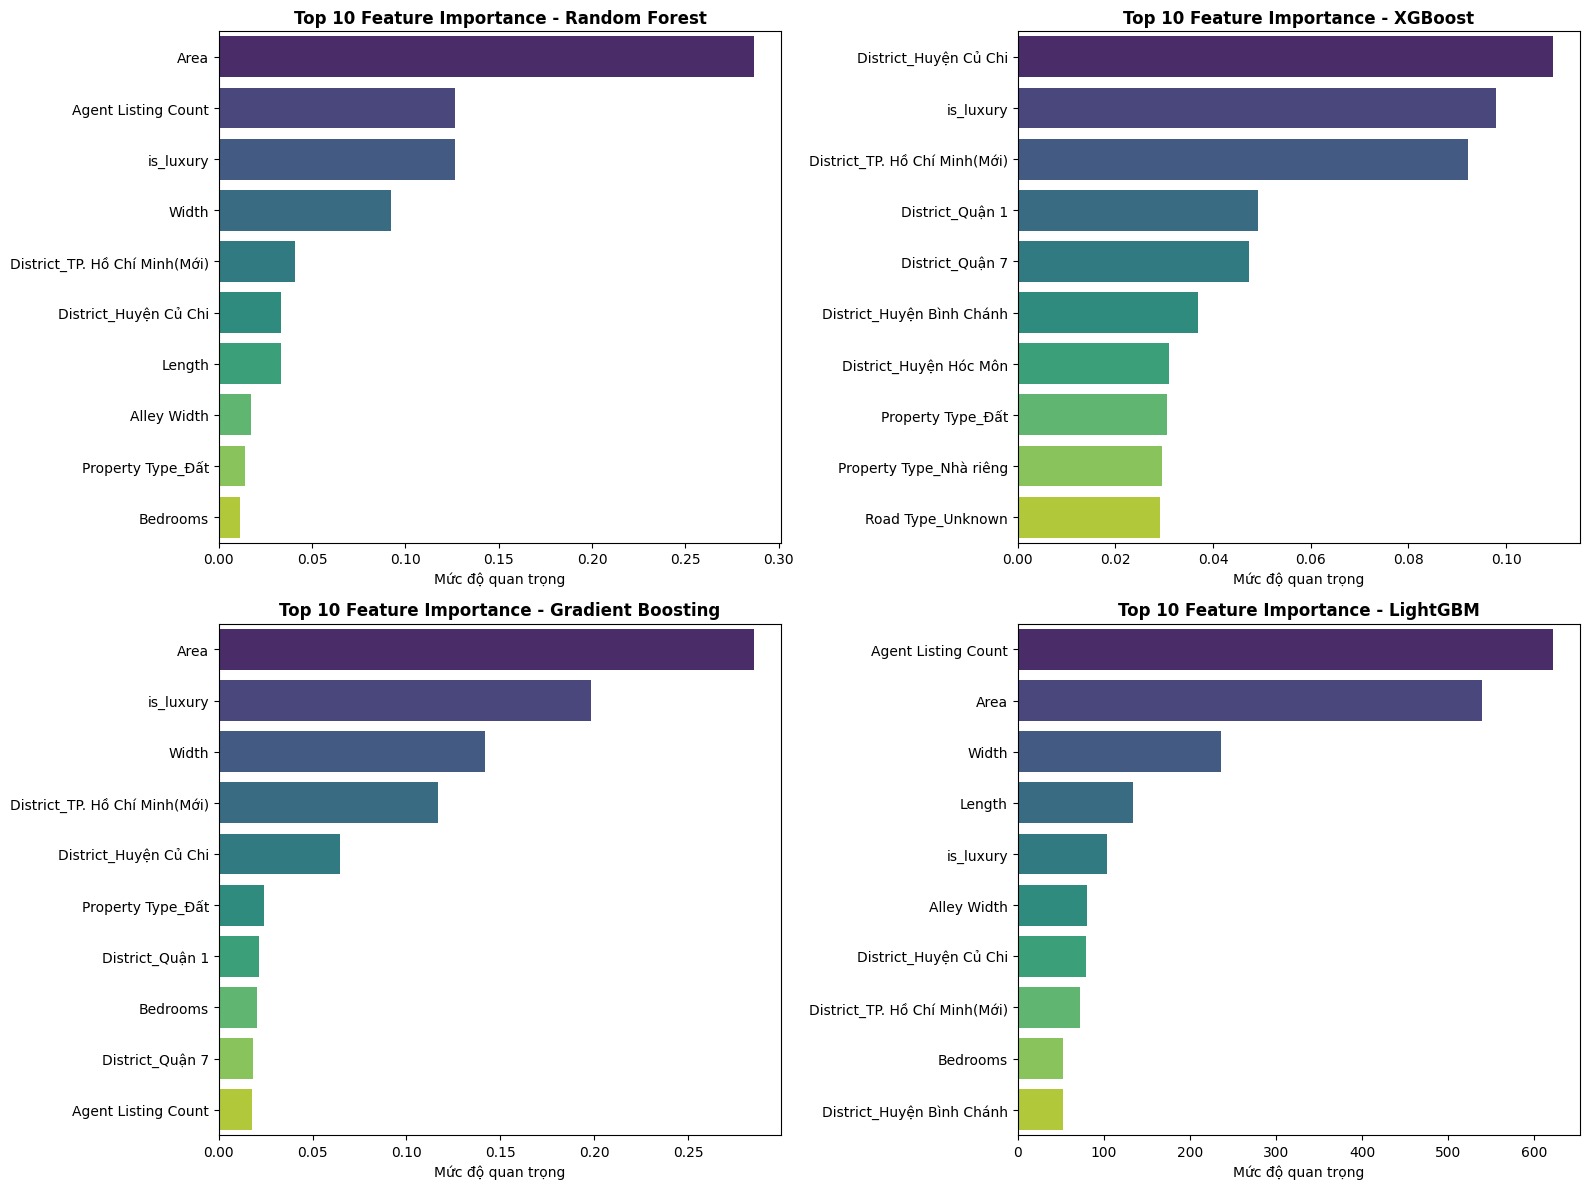

In [21]:
# Cấu hình subplot 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(advanced_models.items()):
    # Lấy feature importance từ thuộc tính mô hình
    importances = model.feature_importances_
    feature_names = X_train.columns

    # Tạo DataFrame để sắp xếp và chọn ra top 10
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)

    # Vẽ biểu đồ thanh ngang (Đã fix FutureWarning bằng hue và legend=False)
    sns.barplot(
        x='Importance',
        y='Feature',
        data=df_importance,
        ax=axes[idx],
        palette='viridis',
        hue='Feature',      # Gán biến trục y cho hue
        legend=False        # Ẩn bảng chú thích (legend) để biểu đồ gọn gàng
    )
    axes[idx].set_title(f'Top 10 Feature Importance - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Mức độ quan trọng')
    axes[idx].set_ylabel('')

plt.tight_layout()
# Lưu biểu đồ vào folder kết quả
plt.savefig('./results/model_comparison/top_10_feature_importance.png', dpi=300)
plt.show()

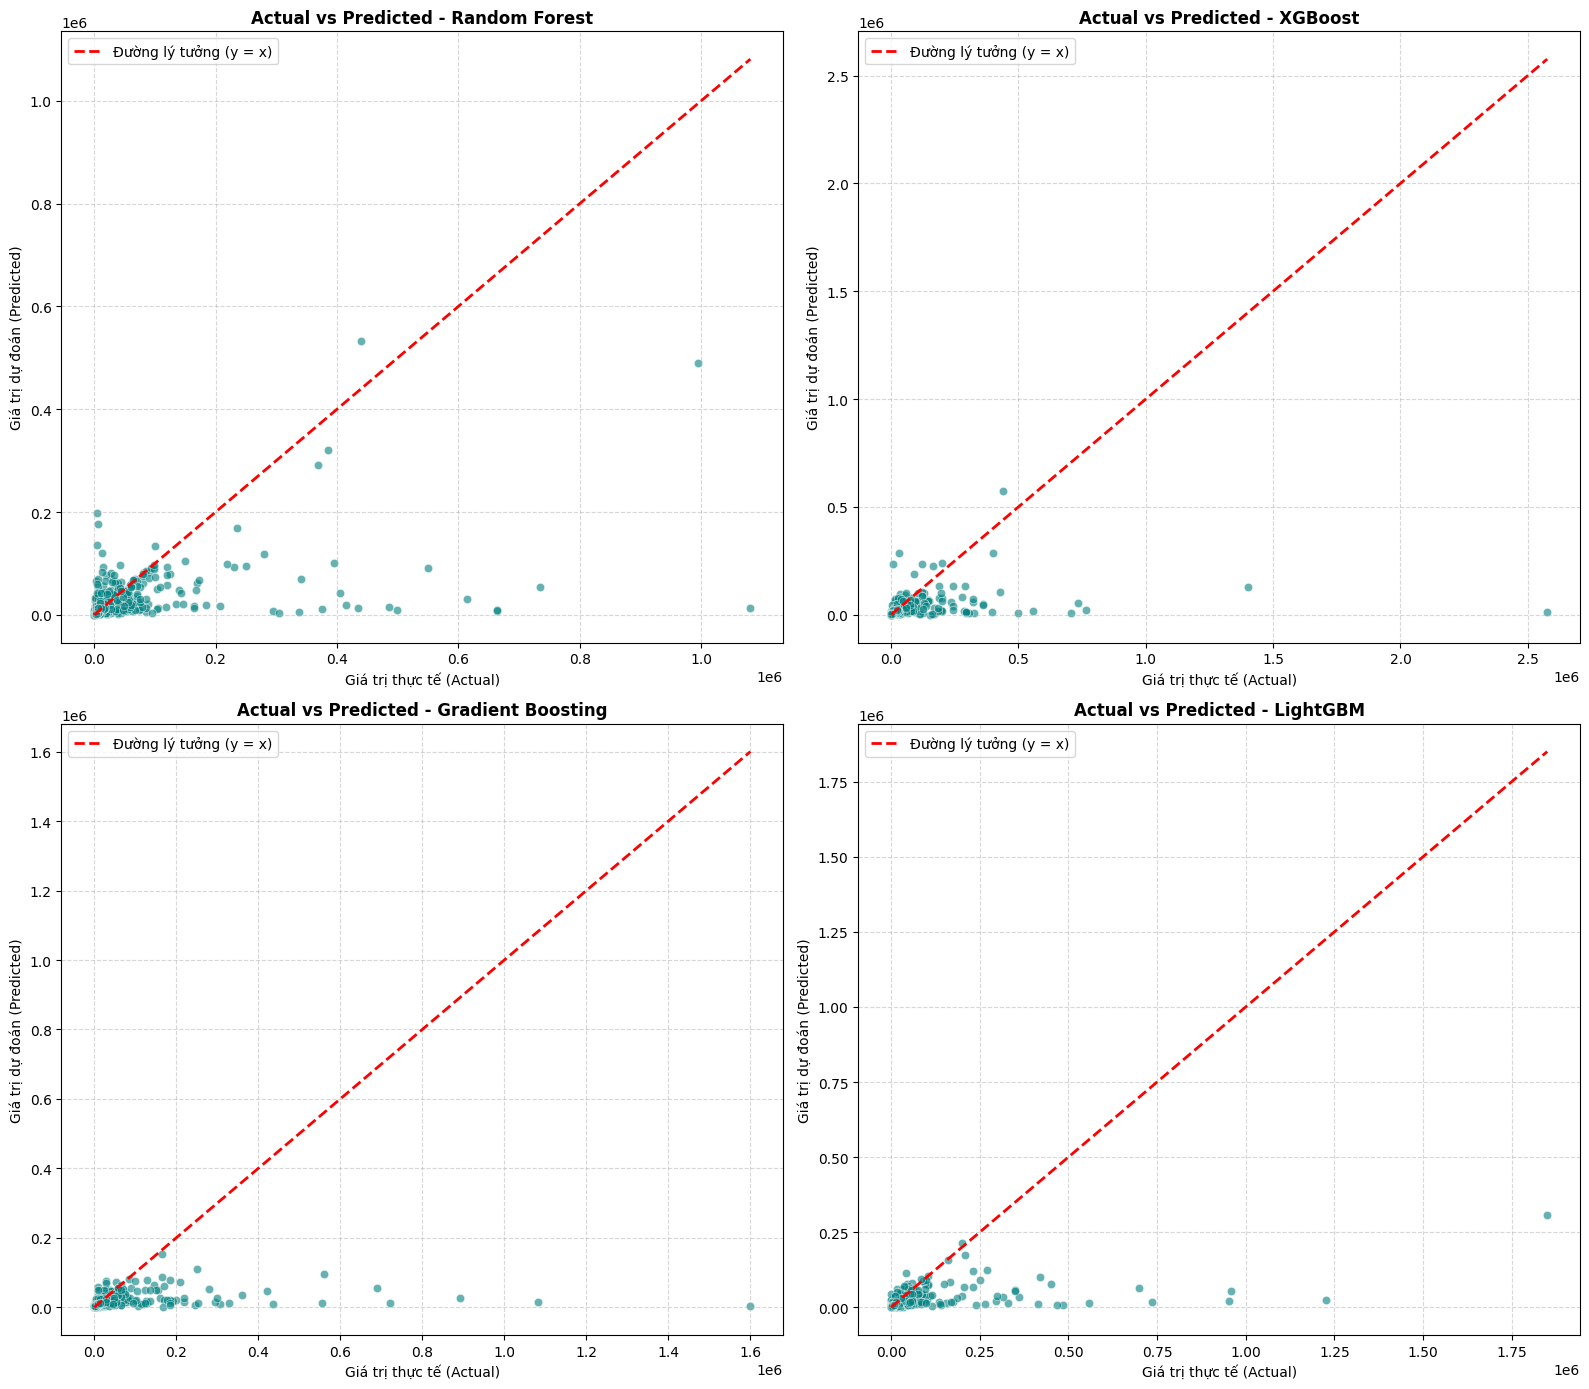

In [22]:
# Cấu hình subplot 2x2 cho biểu đồ So sánh Giá thực tế vs Giá dự đoán
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, pred_actual) in enumerate(predictions_dict.items()):
    # Lấy ngẫu nhiên tối đa 1000 điểm dữ liệu để vẽ nhằm tránh biểu đồ quá dày và nặng máy
    sample_size = min(1000, len(y_test_actual))
    sample_idx = np.random.choice(len(y_test_actual), sample_size, replace=False)

    actual_sampled = y_test_actual.iloc[sample_idx] if isinstance(y_test_actual, pd.Series) else y_test_actual[sample_idx]
    pred_sampled = pred_actual[sample_idx]

    # Vẽ scatter plot điểm phân tán dữ liệu
    sns.scatterplot(
        x=actual_sampled,
        y=pred_sampled,
        alpha=0.6,
        ax=axes[idx],
        color='teal'
    )

    # Đường chéo lý tưởng y = x (Nơi các giá trị dự đoán bằng hoàn toàn giá trị thực tế)
    max_val = max(actual_sampled.max(), pred_sampled.max())
    min_val = min(actual_sampled.min(), pred_sampled.min())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Đường lý tưởng (y = x)')

    axes[idx].set_title(f'Actual vs Predicted - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Giá trị thực tế (Actual)')
    axes[idx].set_ylabel('Giá trị dự đoán (Predicted)')
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# Lưu biểu đồ Actual vs Predicted vào folder kết quả
plt.savefig('./results/model_comparison/actual_vs_predicted.png', dpi=300)
plt.show()